# AI 기본법 RAG 검색·답변 평가

`golden_set_v2.jsonl`의 **45문항(답변 가능 36 / 범위 밖 9)** 을 그대로 사용합니다.

- **A→B**: 조 전체 vs 구조 기반 청킹, **B/C/D**: Dense / BM25 / Hybrid,
  **D→E**: LLM 재정렬, **E→F**: 상위 문맥·참조 조문 확장.
- 현재 정답 라벨은 **조문 단위**입니다. 조문 검색 성공이 해당 항·호·목의 근거 충족을 보장하지 않습니다.
- 항·호·목 라벨이 없는 근거 Recall은 `NaN`(미측정), 범위 밖 질문의 검색 정답 지표도 `NaN`입니다.
- 답변/LLM judge 평가는 자동 보조 지표입니다. 생성과 judge가 같은 설정 모델을 사용하므로 독립적 법률 검증이 아닙니다.

먼저 `uv sync`, 커널은 프로젝트 `.venv`를 선택하세요. **기본 Run All은 저장 결과를 읽으며 API를 재호출하지 않습니다.**
재실행하려면 아래 `RUN_EVALUATION=True`로 바꾸세요. `MODE='full'`은 설정된 외부 API로 공개 법령/질문을 보내며 비용이 발생합니다.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'golden_set_v2.jsonl').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from eval.dataset import load_golden
from eval.evaluate import run_benchmark, summarize, answer_summary
from app.search.cache import digest
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 120})
pd.set_option('display.max_colwidth', 100)
golden = load_golden(ROOT / 'golden_set_v2.jsonl')
golden_df = pd.DataFrame(golden)
RUN_EVALUATION = False
MODE = 'full'  # 'full': A~F + 답변/judge/oracle, 'lexical': API 없이 BM25 (XML 캐시 필요)
RESULT_DIR = ROOT / 'eval/results' / MODE
if os.getenv('RAG_RESULTS_DIR'):
    RESULT_DIR = Path(os.environ['RAG_RESULTS_DIR'])
elif not RUN_EVALUATION and not (RESULT_DIR / 'retrieval_rows.json').exists():
    RESULT_DIR = ROOT / 'eval/results/lexical'
print('Project:', ROOT)
print('Results:', RESULT_DIR)

Project: /home/sunub/gg1th_rag_mini_pjt_template
Results: /home/sunub/gg1th_rag_mini_pjt_template/eval/results/full


## 1. 평가 기준과 데이터 점검

상위 K는 **중복 제거한 조문 순위**이며 후보 청크 개수와 구분됩니다.
`candidate_recall@30`도 실제 후보에서 얻은 고유 조문만 평가합니다.
정답 조문 관련도는 2, `related_articles`만 있는 조문은 1, 나머지는 0입니다.
전체 확보율은 질문의 `answer_articles`를 모두 확보한 질문의 비율입니다.

In [2]:
criteria = pd.DataFrame([
    ['데이터', '원문 단위 보존율 / ID 충돌 / 라벨 존재', 'XML과 실제 검색 청크 비교', '자동'],
    ['후보 검색', 'Recall@20 / @30', '답변 가능 36문항', '자동·조문'],
    ['순위', 'Hit / Recall / MRR / nDCG @1,3,5,10', '중복 제거 조문 순위', '자동·조문'],
    ['컨텍스트', 'Recall / 전체 확보율', '6000 토큰 예산 내 최종 전달 근거', '자동·조문'],
    ['세부 근거', 'evidence Recall / 전체 확보율', 'required_evidence 라벨 필요', '현재 미측정'],
    ['답변', '정답성 / 관련성 / 요점 충족 / 충실성 / 환각', '생성한 응답만', 'LLM judge'],
    ['인용', '출처 원문 일치 / 인용이 주장 지지', '인용이 있는 응답', '자동 + LLM judge'],
    ['거절', 'Precision / Recall / confusion matrix', '답변 가능·불가능 전체', '라벨 비교'],
], columns=['단계', '지표', '대상', '방식'])
display(criteria)
display(golden_df.groupby(['type', 'answerable']).size().rename('문항 수').reset_index())
assert golden_df.id.is_unique
print(f'총 {len(golden_df)}문항, 답변 가능 {golden_df.answerable.sum()}문항')

,단계,지표,대상,방식
0,데이터,원문 단위 보존율 / ID 충돌 / 라벨 존재,XML과 실제 검색 청크 비교,자동
1,후보 검색,Recall@20 / @30,답변 가능 36문항,자동·조문
2,순위,"Hit / Recall / MRR / nDCG @1,3,5,10",중복 제거 조문 순위,자동·조문
3,컨텍스트,Recall / 전체 확보율,6000 토큰 예산 내 최종 전달 근거,자동·조문
4,세부 근거,evidence Recall / 전체 확보율,required_evidence 라벨 필요,현재 미측정
5,답변,정답성 / 관련성 / 요점 충족 / 충실성 / 환각,생성한 응답만,LLM judge
6,인용,출처 원문 일치 / 인용이 주장 지지,인용이 있는 응답,자동 + LLM judge
7,거절,Precision / Recall / confusion matrix,답변 가능·불가능 전체,라벨 비교


,type,answerable,문항 수
0,기타,True,4
1,범위밖,False,9
2,복합,True,5
3,숫자벌칙,True,5
4,신설,True,5
5,의무,True,7
6,일반인표현,True,5
7,정의,True,5


총 45문항, 답변 가능 36문항


## 2. 실행 또는 저장 결과 불러오기

XML은 `.cache/rag/law.xml`, 임베딩과 LLM 응답은 모델·본문·프롬프트별 해시로 캐시합니다.
실험 Qdrant는 프로세스 메모리에 생성하므로 운영 `law_articles` 컬렉션을 변경하지 않습니다.
캐시가 있으면 지연시간은 실제 신규 API 호출의 지연과 다릅니다. 결과 JSON/CSV에는 오류를 별도 기록합니다.

In [3]:
if RUN_EVALUATION:
    result = await run_benchmark(
        golden_path=ROOT / 'golden_set_v2.jsonl', output_dir=RESULT_DIR,
        lexical_only=MODE == 'lexical', answers=MODE == 'full', oracle=MODE == 'full',
    )
if not (RESULT_DIR / 'retrieval_rows.json').exists():
    raise FileNotFoundError('저장된 결과가 없습니다. RUN_EVALUATION=True로 실행하세요.')
read_json = lambda name: json.loads((RESULT_DIR / name).read_text(encoding='utf-8'))
manifest = read_json('manifest.json')
assert manifest['golden_hash'] == digest(golden), '골든셋이 변경되었습니다. 평가를 다시 실행하세요.'
rows = read_json('retrieval_rows.json')
details = read_json('retrieval_details.json')
answer_rows = read_json('answer_rows.json') if (RESULT_DIR / 'answer_rows.json').exists() else []
audit = read_json('corpus_audit.json')
df = pd.DataFrame(rows)
summary = summarize(rows).set_index('experiment')
FIGURES = RESULT_DIR / 'figures'
FIGURES.mkdir(exist_ok=True)
def finish(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f'{name}.png', bbox_inches='tight')
    plt.show()
display(pd.Series(manifest, name='실행 설정').to_frame())
if 'finished_at' not in manifest:
    display(Markdown('**주의: 실행이 완료되지 않은 부분 결과입니다.**'))
display(summary[['questions', 'succeeded', 'failed', 'answerable_measured']])
if not df.status.eq('ok').any():
    display(df[['experiment','id','question','error_type']])

,실행 설정
started_at,2026-10-08T14:54:45.068982+09:00
snapshot_date,2026-07-21
mst,282791
promulgation_no,21311
golden_file,golden_set_v2.jsonl
golden_hash,671e9831699e3324ed2fd4541bc6034bbc2e62e29129f0cf5961b0baf5a236fb
question_count,45
xml_hash,0ec6a7b9d770e645c56d0c0612d793dc1b35dd90fce6f34f8ba6c33a3c3723d4
chunker_version,3
embedding_model,text-embedding-3-small


,questions,succeeded,failed,answerable_measured
experiment,,,,
A_article_dense,45,45,0,36
B_structure_dense,45,45,0,36
C_structure_bm25,45,45,0,36
D_hybrid_rrf,45,45,0,36
E_hybrid_rerank,45,45,0,36
F_rerank_expand,45,45,0,36


,XML 조문,검색 본문 청크,원문 텍스트 단위,원문 보존율,ID 충돌,없는 정답 조문,세부 근거 라벨 문항
0,46,122,414,1.0,0,0,0


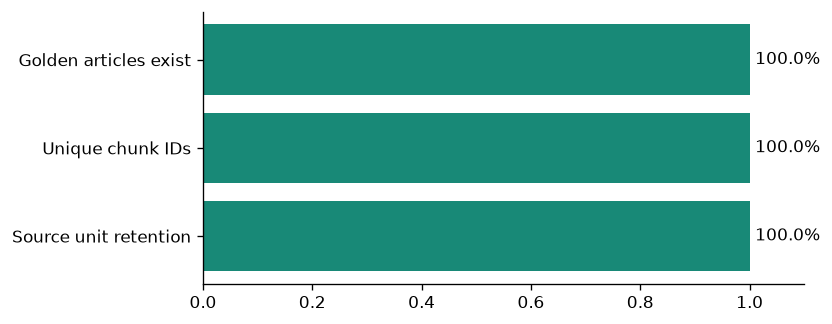

In [4]:
display(pd.DataFrame([{
    'XML 조문': audit['xml_articles'], '검색 본문 청크': audit['searchable_chunks'],
    '원문 텍스트 단위': audit['source_units'], '원문 보존율': audit['source_unit_retention'],
    'ID 충돌': audit['id_collisions'], '없는 정답 조문': len(audit['unknown_golden_articles']),
    '세부 근거 라벨 문항': audit['evidence_labeled_questions'],
}]))
if audit['missing_source_units']:
    display(pd.DataFrame(audit['missing_source_units']))
fig, ax = plt.subplots(figsize=(7, 2.8))
values = [audit['source_unit_retention'], float(audit['id_collisions'] == 0),
          float(not audit['unknown_golden_articles'])]
ax.barh(['Source unit retention', 'Unique chunk IDs', 'Golden articles exist'], values, color='#188977')
ax.set_xlim(0, 1.1)
for i, v in enumerate(values): ax.text(v + .01, i, f'{v:.1%}', va='center')
finish('01_integrity')

## 3. 검색 방식별 비교

답변 가능 질문만 검색 정답 지표 평균에 포함합니다. 범위 밖 질문 9개에 관련 조문이 있더라도 정답 검색 성공으로 취급하지 않습니다.
오류 문항은 평균에서 빠지므로 반드시 위의 **failed** 수도 함께 확인하세요.

,candidate_recall@30,rank_hit@5,rank_recall@5,rank_mrr@10,rank_ndcg@5,context_recall,context_all_required,context_tokens
experiment,,,,,,,,
A_article_dense,0.9444,0.9167,0.8889,0.7764,0.7931,0.9028,0.8889,4626.8667
B_structure_dense,0.9167,0.9167,0.8750,0.7174,0.7453,0.9167,0.8889,3035.8667
C_structure_bm25,0.9722,0.9167,0.8889,0.7786,0.7875,0.9583,0.9167,3444.3778
D_hybrid_rrf,0.9861,1.0000,0.9583,0.8356,0.8545,0.9167,0.8611,3228.0444
E_hybrid_rerank,0.9861,1.0000,0.9769,1.0000,0.9766,0.9861,0.9722,3348.3333
F_rerank_expand,0.9861,1.0000,0.9769,1.0000,0.9766,1.0000,1.0000,4879.2889


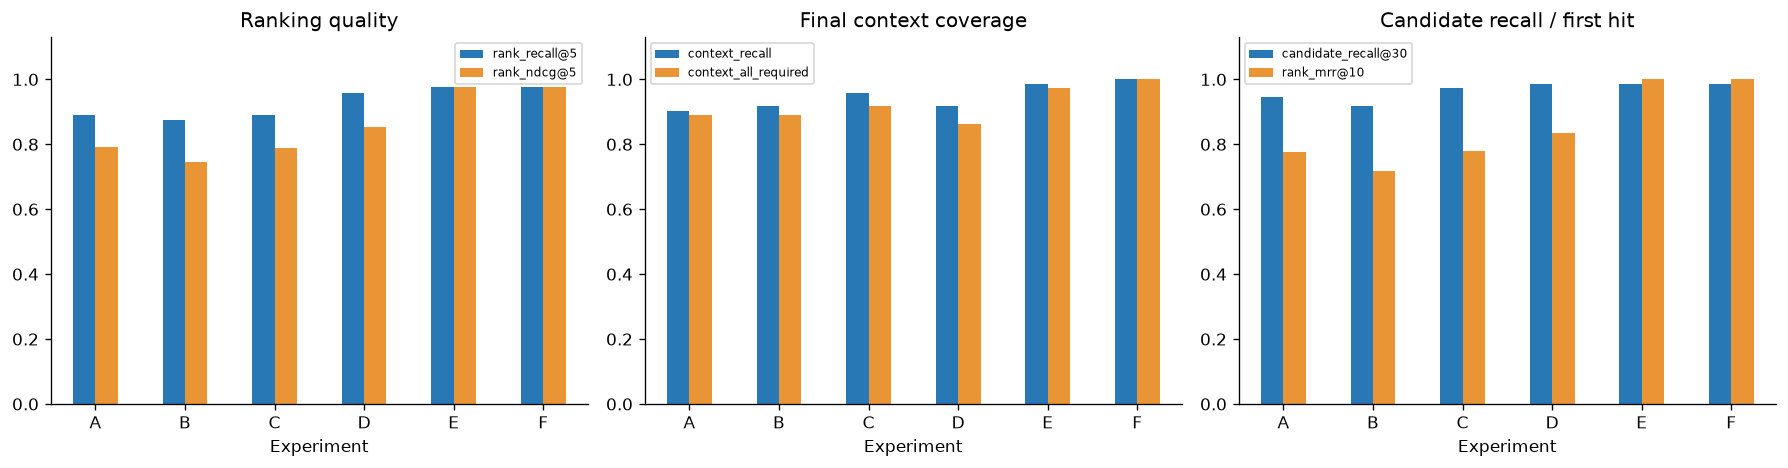

In [5]:
if (df.status.eq('ok') & df.answerable).any():
    columns = ['candidate_recall@30', 'rank_hit@5', 'rank_recall@5', 'rank_mrr@10',
               'rank_ndcg@5', 'context_recall', 'context_all_required', 'context_tokens']
    display(summary.reindex(columns=columns).round(4))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, cols, title in zip(axes,
        [['rank_recall@5', 'rank_ndcg@5'], ['context_recall', 'context_all_required'], ['candidate_recall@30', 'rank_mrr@10']],
        ['Ranking quality', 'Final context coverage', 'Candidate recall / first hit']):
        summary[cols].rename(index=lambda x: x.split('_')[0]).plot.bar(ax=ax, rot=0, color=['#2878b5', '#e99535'])
        ax.set_title(title); ax.set_ylim(0, 1.13); ax.legend(fontsize=7)
        ax.set_xlabel('Experiment')
    finish('02_comparison')
else:
    display(Markdown('성공한 검색 결과가 없어 이 차트는 미측정입니다. 오류 표를 확인하세요.'))

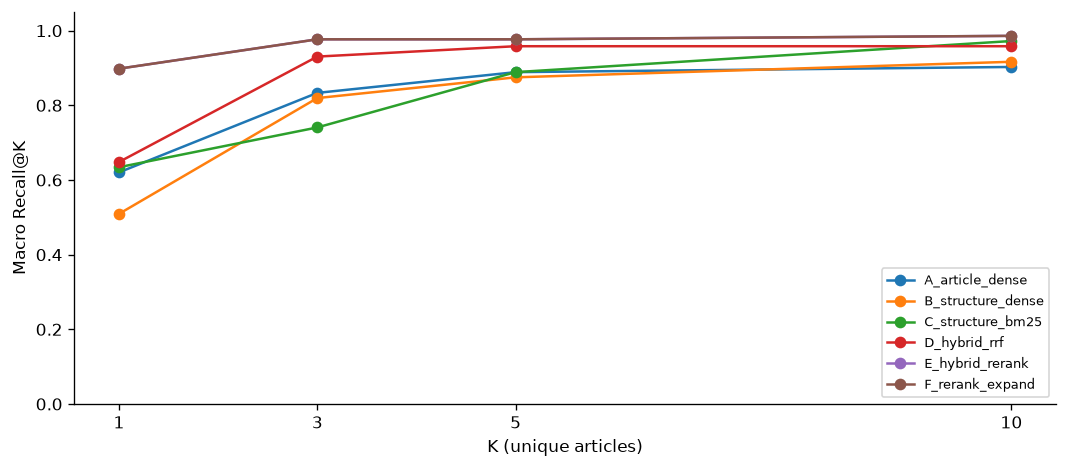

In [6]:
if (df.status.eq('ok') & df.answerable).any():
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, row in summary.iterrows():
        ks = [1, 3, 5, 10]
        ax.plot(ks, [row[f'rank_recall@{k}'] for k in ks], marker='o', label=name)
    ax.set(xlabel='K (unique articles)', ylabel='Macro Recall@K', ylim=(0, 1.05), xticks=ks)
    ax.legend(fontsize=8, loc='lower right')
    finish('03_recall_curve')
else:
    display(Markdown('성공한 검색 결과가 없어 이 차트는 미측정입니다. 오류 표를 확인하세요.'))

## 4. 질문 유형별 품질과 실패 질문

전체 평균이 좋아도 복합·숫자벌칙·신설 조문에서 약할 수 있습니다. 아래 heatmap은 유형별 최종 컨텍스트 전체 확보율입니다.

experiment,A_article_dense,B_structure_dense,C_structure_bm25,D_hybrid_rrf,E_hybrid_rerank,F_rerank_expand
type,,,,,,
기타,1.000,1.000,1.0,1.000,1.0,1.0
복합,1.000,1.000,0.6,0.600,1.0,1.0
숫자벌칙,0.800,0.800,1.0,0.800,1.0,1.0
신설,1.000,1.000,1.0,1.000,1.0,1.0
의무,0.857,0.714,1.0,0.857,1.0,1.0
일반인표현,0.600,0.800,0.8,0.800,0.8,1.0
정의,1.000,1.000,1.0,1.000,1.0,1.0


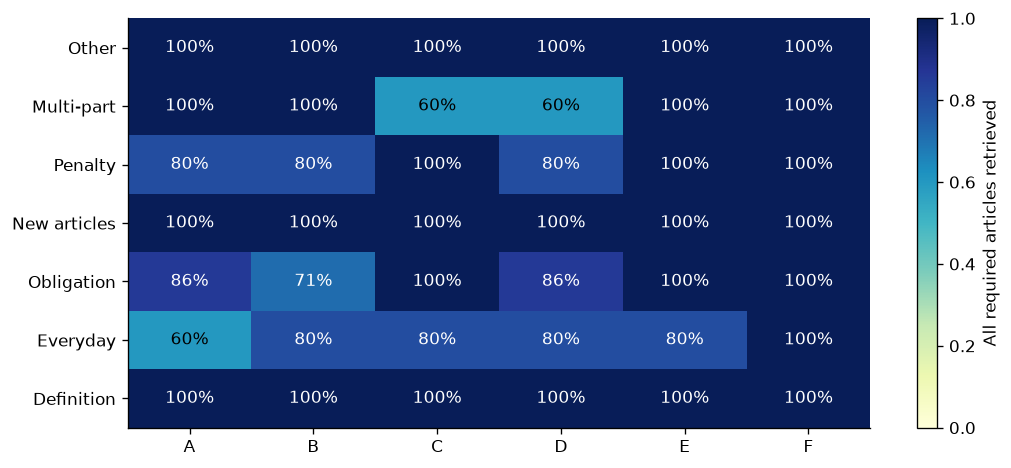

,experiment,id,type,question,missing_articles,context_recall
26,A_article_dense,q12,의무,인공지능 결과에 대해 영향받는 사람은 설명을 요구할 수 있나요?,[제3조],0.0
12,A_article_dense,q15,일반인표현,AI로 채용 평가를 하는 프로그램도 특별히 관리되나요?,[제2조],0.0
23,A_article_dense,q16,일반인표현,AI로 대출 심사를 하면 어떤 규제를 받나요?,"[제2조, 제34조]",0.0
9,A_article_dense,q19,숫자벌칙,고영향 인공지능 관련 자료 제출이나 조사에 응하지 않으면 어떻게 되나요?,[제43조],0.5
60,B_structure_dense,q09,의무,학습에 많은 연산량을 쓴 인공지능은 어떤 의무가 있나요?,[제32조],0.0
48,B_structure_dense,q12,의무,인공지능 결과에 대해 영향받는 사람은 설명을 요구할 수 있나요?,[제3조],0.0
47,B_structure_dense,q16,일반인표현,AI로 대출 심사를 하면 어떤 규제를 받나요?,[제34조],0.5
78,B_structure_dense,q19,숫자벌칙,고영향 인공지능 관련 자료 제출이나 조사에 응하지 않으면 어떻게 되나요?,[제43조],0.5
133,C_structure_bm25,q16,일반인표현,AI로 대출 심사를 하면 어떤 규제를 받나요?,[제34조],0.5
92,C_structure_bm25,q25,복합,AI 안전과 관련된 정부 기관에는 어떤 곳이 있나요?,[제11조],0.5


In [7]:
if (df.status.eq('ok') & df.answerable).any():
    TYPE_EN = {'정의':'Definition', '의무':'Obligation', '일반인표현':'Everyday',
               '숫자벌칙':'Penalty', '복합':'Multi-part', '신설':'New articles', '기타':'Other', '범위밖':'Out of scope'}
    ok = df[df.status.eq('ok')].copy()
    answerable = ok[ok.answerable].copy()
    heat = answerable.pivot_table(index='type', columns='experiment', values='context_all_required', aggfunc='mean')
    display(heat.round(3))
    fig, ax = plt.subplots(figsize=(max(7, len(heat.columns)*1.5), 4))
    image = ax.imshow(heat.to_numpy(dtype=float), vmin=0, vmax=1, cmap='YlGnBu', aspect='auto')
    ax.set_xticks(range(len(heat.columns)), [n.split('_')[0] for n in heat.columns])
    ax.set_yticks(range(len(heat.index)), [TYPE_EN.get(n, n) for n in heat.index])
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            v = heat.iloc[i,j]
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', color='white' if v > .65 else 'black')
    fig.colorbar(image, ax=ax, label='All required articles retrieved')
    finish('04_category_heatmap')
    failures = answerable[answerable.context_all_required.lt(1)]
    display(failures[['experiment','id','type','question','missing_articles','context_recall']].sort_values(['experiment','id']))
    errors = df[df.status.ne('ok')]
    if len(errors): display(errors[['experiment','id','question','error_type']])
else:
    display(Markdown('성공한 검색 결과가 없어 이 차트는 미측정입니다. 오류 표를 확인하세요.'))

## 5. 질문별 검색 결과 탐색

`QUESTION_ID`와 `EXPERIMENT`를 바꾸면 후보 순위, 최종 전달 근거, 누락 조문을 확인할 수 있습니다.
검색 점수는 Dense/BM25/RRF/Reranker마다 척도가 달라 서로 직접 비교하지 않습니다.

In [8]:
QUESTION_ID = 'q16'
EXPERIMENT = 'F_rerank_expand' if 'F_rerank_expand' in df.experiment.values else df.experiment.iloc[0]
def inspect_question(question_id, experiment):
    question = next(q for q in golden if q['id'] == question_id)
    detail = next(d for d in details if d['id'] == question_id and d['experiment'] == experiment)
    display(Markdown(f"**{question_id}: {question['question']}**"))
    print('정답 조문:', question['answer_articles'], '| 답변 가능:', question['answerable'])
    if detail['status'] != 'ok':
        display(detail); return
    for stage in ['candidates', 'ranked', 'context']:
        print(stage)
        table = pd.DataFrame(detail[stage])
        if not table.empty:
            table.insert(0, 'rank', range(1, len(table)+1))
            table['gold_article'] = table.article.isin(question['answer_articles'])
            display(table[['rank','article','gold_article','method','score','content']].head(12))
    for record in answer_rows:
        if record['id'] == question_id and record['experiment'] == experiment:
            display(record)
inspect_question(QUESTION_ID, EXPERIMENT)

**q16: AI로 대출 심사를 하면 어떤 규제를 받나요?**

정답 조문: ['제2조', '제34조'] | 답변 가능: True
candidates


,rank,article,gold_article,method,score,content
0,1,제40조,False,rrf,0.032266,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제5장 보칙\n제40조(사실조사 등)\n① 과학기술정보통신부장관은 다음 각 호의 어느 하나에 해당하는 경우에는 인공지능...
1,2,제2조,True,rrf,0.031754,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 사목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
2,3,제19조,False,rrf,0.016393,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제3장 인공지능기술 개발 및 산업 육성 > 제2절 인공지능기술 개발 및 인공지능산업 활성화\n제19조(인공지능 융합의 ...
3,4,제42조,False,rrf,0.016129,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제6장 벌칙\n제42조(벌칙) 제7조제9항을 위반하여 직무상 알게 된 비밀을 타인에게 누설하거나 직무상 목적 외의 용도...
4,5,제36조,False,rrf,0.015873,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제4장 인공지능윤리 및 신뢰성 확보\n제36조(국내대리인 지정)\n① 국내에 주소 또는 영업소가 없는 인공지능사업자로서...
5,6,제8조,False,rrf,0.015625,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제2장 인공지능의 건전한 발전과 신뢰 기반 조성을 위한 추진체계\n제8조(위원회의 기능) 제1항 제5호\n[상위]\n제...
6,7,제9조,False,rrf,0.015385,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제2장 인공지능의 건전한 발전과 신뢰 기반 조성을 위한 추진체계\n제9조(위원의 제척ㆍ기피 및 회피)\n① 위원회의 위...
7,8,제4조,False,rrf,0.015152,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제4조(적용범위)\n① 이 법은 국외에서 이루어진 행위라도 국내 시장 또는 이용자에게 영향을 미치는 경우...
8,9,제2조,True,rrf,0.014925,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 차목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
9,10,제2조,True,rrf,0.014706,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 아목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...


ranked


,rank,article,gold_article,method,score,content
0,1,제2조,True,llm_rerank,4.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 사목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
1,2,제4조,False,llm_rerank,2.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제4조(적용범위)\n① 이 법은 국외에서 이루어진 행위라도 국내 시장 또는 이용자에게 영향을 미치는 경우...
2,3,제43조,False,llm_rerank,2.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제6장 벌칙\n제43조(과태료)\n① 다음 각 호의 어느 하나에 해당하는 자에게는 3천만원 이하의 과태료를 부과한다.\...
3,4,제40조,False,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제5장 보칙\n제40조(사실조사 등)\n① 과학기술정보통신부장관은 다음 각 호의 어느 하나에 해당하는 경우에는 인공지능...
4,5,제36조,False,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제4장 인공지능윤리 및 신뢰성 확보\n제36조(국내대리인 지정)\n① 국내에 주소 또는 영업소가 없는 인공지능사업자로서...
5,6,제2조,True,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 차목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
6,7,제2조,True,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 바목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
7,8,제2조,True,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 다목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
8,9,제2조,True,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 자목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...
9,10,제2조,True,llm_rerank,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 제4호 카목\n[상위]\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개...


context


,rank,article,gold_article,method,score,content
0,1,제2조,True,parent,4.0,"[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2026.1.20>\n 1. ""인공..."
1,2,제4조,False,parent,2.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제1장 총칙\n제4조(적용범위)\n① 이 법은 국외에서 이루어진 행위라도 국내 시장 또는 이용자에게 영향을 미치는 경우...
2,3,제43조,False,parent,2.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제6장 벌칙\n제43조(과태료)\n① 다음 각 호의 어느 하나에 해당하는 자에게는 3천만원 이하의 과태료를 부과한다.\...
3,4,제40조,False,parent,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제5장 보칙\n제40조(사실조사 등)\n① 과학기술정보통신부장관은 다음 각 호의 어느 하나에 해당하는 경우에는 인공지능...
4,5,제36조,False,parent,1.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제4장 인공지능윤리 및 신뢰성 확보\n제36조(국내대리인 지정)\n① 국내에 주소 또는 영업소가 없는 인공지능사업자로서...
5,6,제31조,False,reference,0.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제4장 인공지능윤리 및 신뢰성 확보\n제31조(인공지능 투명성 확보 의무)\n① 인공지능사업자는 고영향 인공지능이나 생...
6,7,제32조,False,reference,0.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제4장 인공지능윤리 및 신뢰성 확보\n제32조(인공지능 안전성 확보 의무)\n① 인공지능사업자는 학습에 사용된 누적 연...
7,8,제34조,True,reference,0.0,[인공지능 발전과 신뢰 기반 조성 등에 관한 기본법] 제4장 인공지능윤리 및 신뢰성 확보\n제34조(고영향 인공지능과 관련한 사업자의 책무)\n① 인공지능사업자는 고영향 인...


{'experiment': 'F_rerank_expand',
 'id': 'q16',
 'type': '일반인표현',
 'question': 'AI로 대출 심사를 하면 어떤 규제를 받나요?',
 'expected_answerable': True,
 'status': 'ok',
 'response': {'answer': 'AI로 대출 심사를 하는 경우, 발췌상 그 활용은 사람의 권리·의무 관계에 중대한 영향을 미치는 판단 또는 평가에 해당하는 영역으로서 ‘고영향 인공지능’에 포함됩니다.[S1] 따라서 해당 AI를 제공하는 인공지능사업자는 고영향 인공지능 또는 이를 이용한 제품·서비스를 제공할 때 안전성·신뢰성 확보 조치와 투명성 확보 의무를 부담할 수 있습니다.[S8][S6]\n\n확인 가능한 규제는 다음과 같습니다.\n- 사전 고지: 고영향 인공지능이나 생성형 인공지능을 이용한 제품 또는 서비스를 제공하려는 경우, 그 서비스가 해당 인공지능에 기반하여 운용된다는 사실을 이용자에게 사전에 고지해야 합니다.[S6]\n- 안전성 확보: 학습에 사용된 누적 연산량이 대통령령 기준 이상인 인공지능시스템은 위험 식별·평가·완화, 위험관리체계 구축을 해야 하고, 그 이행 결과를 과학기술정보통신부장관에게 제출해야 합니다.[S7]\n- 고영향 인공지능 관련 조치: 위험관리방안 수립·운영, 설명 방안 수립·시행, 이용자 보호 방안 수립·운영, 사람의 관리·감독, 관련 문서 작성·보관 등을 대통령령에 따라 이행해야 합니다.[S8]\n\n다만, 이 발췌만으로는 대출 심사 AI에 대해 적용되는 구체적 요건의 세부 기준, 절차, 면제 여부, 그리고 사안별로 어떤 조치가 반드시 필요한지는 확인되지 않습니다. 특히 대통령령으로 정하는 기준과 방법에 위임된 부분이 있어, 그 상세 내용은 이 발췌만으로 답할 수 없습니다.[S6][S7][S8]\n\n제재는 다음과 같이 확인됩니다.\n- 제31조제1항 위반 고지 불이행, 제36조제1항 위반 국내대리인 미지정, 제40조제3항의 중지·시정명령 불이

## 6. 동일 질문 기준 개선량과 비용

가능한 경우 D(Hybrid)를 기준으로 E/F의 질문별 차이를 비교합니다. 부트스트랩 신뢰구간은
동일 문항을 묶어 2,000번 재표집한 기술적 요약입니다. 45문항은 작은 평가셋이고,
이 결과로 설정을 고르면 더 이상 독립된 최종 테스트셋이 아닙니다.

,vs,n,mean_delta,ci_low,ci_high,improved,worse
0,A_article_dense,36,-0.013889,-0.097222,0.055556,2,2
1,B_structure_dense,36,0.000000,-0.069444,0.055556,2,1
2,C_structure_bm25,36,0.041667,0.000000,0.111111,2,0
3,E_hybrid_rerank,36,0.069444,0.013889,0.138889,4,0
4,F_rerank_expand,36,0.083333,0.013889,0.152778,5,0


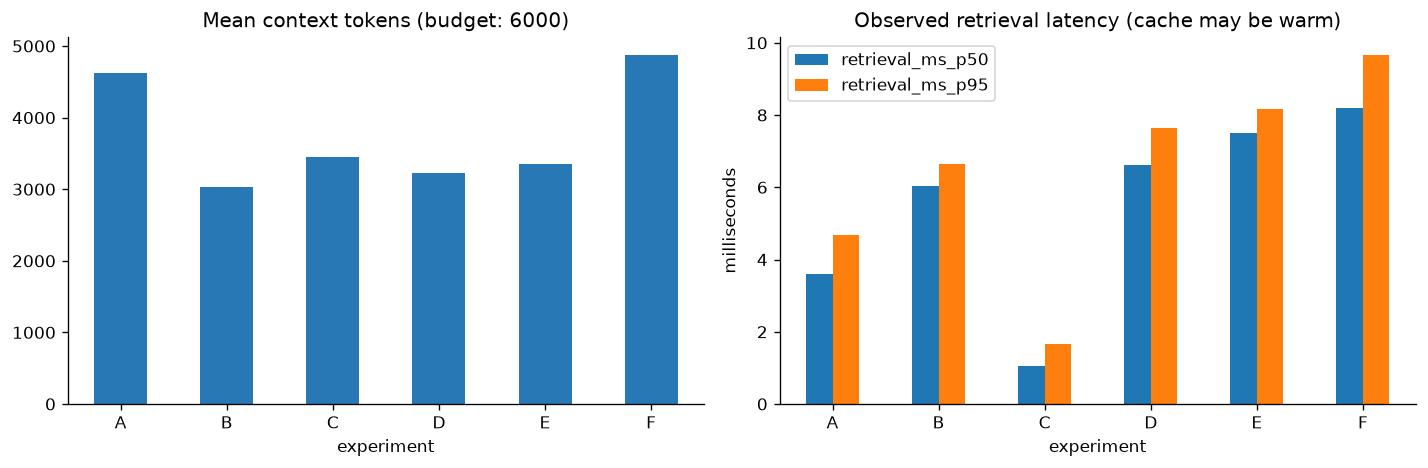

In [9]:
if (df.status.eq('ok') & df.answerable).any():
    baseline = 'D_hybrid_rrf' if 'D_hybrid_rrf' in df.experiment.values else df.experiment.iloc[0]
    pivot = answerable.pivot(index='id', columns='experiment', values='context_recall')
    comparisons = []
    rng = np.random.default_rng(42)
    if baseline not in pivot.columns:
        print('기준 실험의 성공 결과가 없어 실험 간 개선량은 미측정입니다.')
    for name in (pivot.columns if baseline in pivot.columns else []):
        if name == baseline: continue
        paired = pivot[[baseline, name]].dropna()
        delta = (paired[name]-paired[baseline]).to_numpy()
        if not len(delta): continue
        boot = rng.choice(delta, size=(2000, len(delta)), replace=True).mean(axis=1)
        comparisons.append({'vs':name, 'n':len(delta), 'mean_delta':delta.mean(),
                            'ci_low':np.quantile(boot,.025), 'ci_high':np.quantile(boot,.975),
                            'improved':int((delta>0).sum()), 'worse':int((delta<0).sum())})
    display(pd.DataFrame(comparisons))
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    summary[['context_tokens']].rename(index=lambda x:x.split('_')[0]).plot.bar(ax=axes[0],legend=False,rot=0,color='#2878b5')
    axes[0].set_title('Mean context tokens (budget: 6000)')
    summary[['retrieval_ms_p50','retrieval_ms_p95']].rename(index=lambda x:x.split('_')[0]).plot.bar(ax=axes[1],rot=0)
    axes[1].set_title('Observed retrieval latency (cache may be warm)')
    axes[1].set_ylabel('milliseconds')
    finish('05_tokens_latency')
else:
    display(Markdown('성공한 검색 결과가 없어 이 차트는 미측정입니다. 오류 표를 확인하세요.'))

## 7. 답변·인용·거절 평가

- `citation_validity`: 반환한 출처 ID와 원문이 실제 컨텍스트에 존재하는 비율. **주장 타당성과는 다릅니다.**
- `citation_support`: 답변의 각 법률 주장을 붙은 인용이 뒷받침하는지 LLM 판정.
- `faithfulness`: 각 법률 주장이 컨텍스트에 의해 뒷받침되는 비율.
- 주장 없는 순수 거절은 충실성/환각 지표를 미측정 처리합니다.
- 외부 호출 실패와 judge 실패는 별도로 세며 거절 성공으로 세지 않습니다.

,refusal_precision,refusal_recall,answerability_accuracy,true_refusal,false_refusal,missed_refusal,true_answer,measured,missing,retrieval_errors,...,relevance_n,point_coverage,point_coverage_n,faithfulness,faithfulness_n,citation_support,citation_support_n,hallucination,hallucination_n,citation_validity
experiment,,,,,,,,,,,,,,,,,,,,,
F_rerank_expand,0.5294,1.0,0.8222,9,8,0,28,45,0,0,...,45,0.9778,45,0.9715,45,0.9309,45,0.1111,45,1.0
oracle_gold_articles,0.0000,NaN,0.8611,0,5,0,31,36,0,0,...,36,1.0000,36,0.9745,36,0.9250,36,0.0833,36,1.0


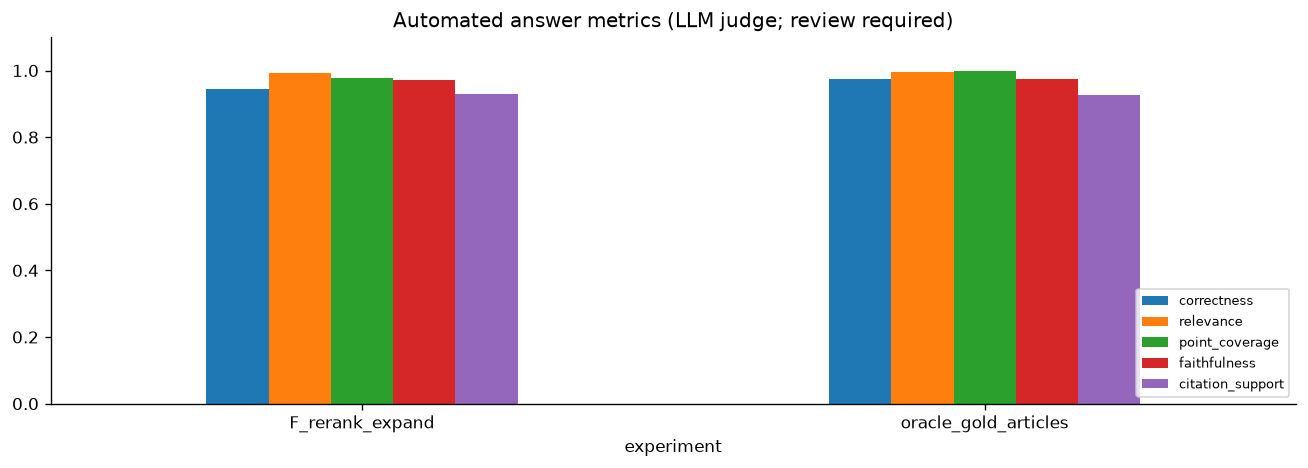

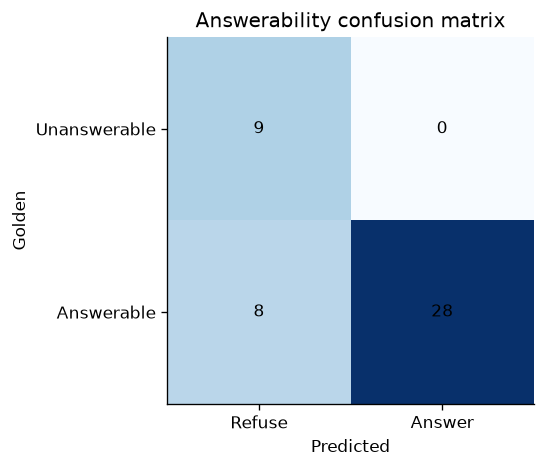

,id,experiment,status,expected,predicted,answer,judge,judge_status
0,q01,F_rerank_expand,ok,True,True,"고영향 인공지능이란 사람의 생명, 신체의 안전 및 기본권에 중대한 영향을 미치거나 위험을 초래할 우려가 있는 인공지능시스템으로서, 법에서 정한 다음 각 영역 중 하나에서 활...","응답은 제2조 제4호의 정의와 제33조 제1항의 확인 절차를 정확히 반영한다. 다만 첫 문장은 정의의 핵심을 잘 옮겼지만, 원문상 ‘다음 각 목의 어느 하나의 영역에서 활용...",ok
1,q31,F_rerank_expand,ok,True,True,"제공된 발췌에 따르면, AI 창업 지원 자금(제18조 제3항에 따른 벤처투자모태조합을 활용한 지원을 위한 자금)은 다음 재원으로 조성합니다: ① 국가·지방자치단체·공공기관의...",답변의 핵심 재원 구성은 제18조 제4항 제1호~제3호와 일치하여 정답 요점을 모두 충족합니다. 다만 질문은 '어떤 재원으로 마련하나요'이므로 부가적으로 언급한 제5항의 대...,ok
2,q14,F_rerank_expand,ok,True,True,"네. 제공된 발췌에 따르면, 인공지능사업자가 고영향 인공지능이나 생성형 인공지능을 이용한 제품 또는 서비스를 제공하려는 경우에는 그 제품 또는 서비스가 해당 인공지능에 기반...","답변의 핵심은 컨텍스트 제31조 제1항과 제2항에 부합하므로 정답 요점은 충족된다. 다만 질문은 '사용자에게 AI라는 사실을 알려야 하나요'인데, 답변은 생성형 인공지능 여...",ok
3,q10,F_rerank_expand,ok,True,True,"네. 인공지능사업자는 인공지능 또는 이를 이용한 제품ㆍ서비스를 제공하는 경우, 그 인공지능이 고영향 인공지능에 해당하는지 사전에 검토하여야 합니다. 필요하면 과학기술정보통신...","응답은 질문에 직접 대응하는 두 핵심 요점(사전 검토 의무, 장관에게 확인 요청 가능)을 모두 정확히 포함한다. 추가로 고영향 인공지능의 정의와 절차의 대통령령 위임까지 언...",ok
4,q27,F_rerank_expand,ok,True,True,예. 과학기술정보통신부장관은 관계 중앙행정기관의 장 및 지방자치단체의 장의 의견을 들어 **3년마다** 인공지능 기본계획을 수립·변경 및 시행하여야 합니다. 다만 기본계획 ...,"질문은 기본계획 수립 주기를 묻고 있고, 제시된 법문에는 '3년마다'라고 명시되어 있어 정답 요점을 정확히 충족한다. 부가적으로 예외 조항도 법문과 일치한다. 답변의 주장은...",ok
...,...,...,...,...,...,...,...,...
76,q34,oracle_gold_articles,ok,True,True,"네, 가능합니다. 제28조 제1항에 따르면 인공지능기술 연구 및 개발을 수행하는 사람이 소속된 교육기관·연구기관, 인공지능사업자, 그 밖에 대통령령으로 정하는 인공지능기술 ...","질문에 대한 핵심 답변은 법 조문 제28조 제1항에 의해 직접 뒷받침됩니다. 사용자는 민간에서 자율적으로 AI 윤리위원회를 만들 수 있는지 물었고, 제시된 답변은 교육기관·...",ok
77,q28,oracle_gold_articles,ok,True,True,"네, 가능합니다. 다만 누구에게나 자동으로 주어지는 것은 아니고, 경제적 여건 때문에 인공지능제품 또는 인공지능서비스를 이용하기 어려운 사람에 대해 국가와 지방자치단체가 예...","답변은 제17조의2 제1항의 핵심을 정확히 반영하고 있으며, 질문의 답으로서 '지원받을 수 있나'에 대해 가능하다고 적절히 응답했다. 다만 지원이 자동·보편적으로 주어지는 ...",ok
78,q22,oracle_gold_articles,ok,True,True,과태료는 대통령령으로 정하는 바에 따라 과학기술정보통신부장관이 부과·징수합니다. [S1],"답변은 제43조 제2항의 문언과 정확히 일치하며, 주체(과학기술정보통신부장관), 절차적 기준(대통령령으로 정하는 바), 작용(부과·징수)이 모두 원문과 부합한다. 별도의 충...",ok
79,q16,oracle_gold_articles,ok,True,True,"제공된 발췌만으로 보면, AI를 이용한 대출 심사는 ‘고영향 인공지능’에 해당할 수 있습니다. 정의상 ‘채용, 대출 심사 등 개인의 권리·의무 관계에 중대한 영향을 미치는 ...","답변은 제2조 제4호 사목과 제34조 제1항~제2항의 문언에 대체로 정확히 부합합니다. 다만 마지막 문장은 ‘발췌에 없다’는 메타 진술로, 원문 조문 자체로 직접 뒷받침되는...",ok


In [10]:
if not answer_rows:
    display(Markdown('**답변 평가는 미실행입니다.** 전체 API 평가를 실행하면 이 영역이 채워집니다.'))
else:
    ans_summary = answer_summary(answer_rows).set_index('experiment')
    display(ans_summary.round(4))
    metrics = ['correctness','relevance','point_coverage','faithfulness','citation_support']
    if ans_summary.judged.sum() > 0:
        fig, ax = plt.subplots(figsize=(11,4))
        ans_summary[metrics].plot.bar(ax=ax, rot=0, ylim=(0,1.1))
        ax.set_title('Automated answer metrics (LLM judge; review required)')
        ax.legend(fontsize=8, loc='lower right')
        finish('06_answer_quality')
    else:
        print('Judge 성공 결과 없음: 차트 미측정')
    if 'F_rerank_expand' in ans_summary.index:
        r = ans_summary.loc['F_rerank_expand']
        matrix = np.array([[r.true_refusal, r.missed_refusal], [r.false_refusal, r.true_answer]], dtype=int)
        fig, ax = plt.subplots(figsize=(5,4))
        ax.imshow(matrix,cmap='Blues')
        ax.set_xticks([0,1], ['Refuse','Answer']); ax.set_yticks([0,1], ['Unanswerable','Answerable'])
        ax.set(xlabel='Predicted',ylabel='Golden',title='Answerability confusion matrix')
        for (i,j),value in np.ndenumerate(matrix): ax.text(j,i,str(value),ha='center',va='center')
        finish('07_refusal_matrix')
    review = [{'id':r['id'],'experiment':r['experiment'],'status':r['status'],
               'expected':r['expected_answerable'],'predicted':r.get('response',{}).get('is_answerable'),
               'answer':r.get('response',{}).get('answer'),
               'judge':r.get('judge',{}).get('explanation'), 'judge_status':r.get('judge_status')}
              for r in answer_rows]
    display(pd.DataFrame(review))

## 8. 정답 조문 직접 제공(Oracle) 진단

Oracle은 `answer_articles`의 전체 조문을 직접 넣습니다. **정답을 사용한 생성 진단이므로 검색 실험 점수에 포함하지 않습니다.**
범위 밖 질문은 Oracle 대상에서 제외하며, 컨텍스트 예산으로 정답 조문이 빠진 경우도 별도 표시합니다.
F와 Oracle의 정답성을 비교하면 검색 근거 부족인지 생성·해석 문제인지 검토할 수 있습니다.

experiment,F_rerank_expand,oracle_gold_articles,oracle_minus_retrieved
id,,,
q25,0.20,0.98,0.78
q32,0.92,1.00,0.08
q35,0.95,1.00,0.05
q16,0.95,0.99,0.04
q33,0.96,1.00,0.04
q02,0.97,1.00,0.03
q01,0.98,1.00,0.02
q15,0.96,0.98,0.02
q13,0.98,1.00,0.02


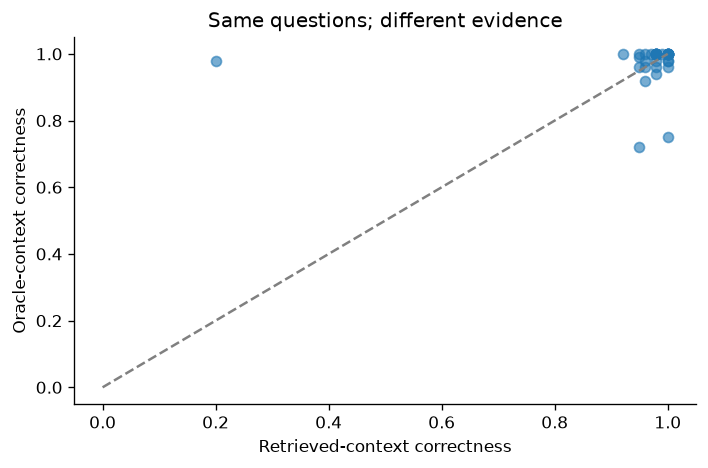

In [11]:
if answer_rows:
    scores = pd.DataFrame([{'id':r['id'],'experiment':r['experiment'],
                           'correctness':r.get('judge',{}).get('correctness'),
                           'oracle_complete':r.get('oracle_complete',True)} for r in answer_rows])
    paired = scores[scores.oracle_complete].pivot(index='id',columns='experiment',values='correctness')
    if {'F_rerank_expand','oracle_gold_articles'}.issubset(paired.columns):
        paired = paired.dropna()
        paired['oracle_minus_retrieved'] = paired.oracle_gold_articles-paired.F_rerank_expand
        display(paired.sort_values('oracle_minus_retrieved',ascending=False))
        fig, ax = plt.subplots(figsize=(6,4))
        ax.scatter(paired.F_rerank_expand,paired.oracle_gold_articles,alpha=.6)
        ax.plot([0,1],[0,1],'--',color='gray')
        ax.set(xlabel='Retrieved-context correctness',ylabel='Oracle-context correctness',
               title='Same questions; different evidence')
        finish('08_oracle')
    else:
        print('Oracle 결과 없음')

## 9. 결과 내보내기와 다음 실험

JSON에는 원문 근거와 질문별 trace, CSV에는 집계 및 문항별 지표, `figures/`에는 PNG가 저장됩니다.
미측정 영역을 0으로 채우지 않고 유지합니다. 세부 근거 평가는 원본을 보존한 별도 검수본에
`required_evidence`를 추가해야 합니다. 모델·청크 크기·K를 바꿀 때는 다른 결과 디렉터리를 사용하세요.

골든셋의 정답 요점도 사람이 검토해야 합니다. 예를 들어 일상 질문의 적용 주체/조건이나
복합 질문의 '전부' 범위는 조문 목록만으로 법률적 완전성을 보장하지 않습니다.

In [12]:
summary.to_csv(RESULT_DIR / 'retrieval_summary.csv')
if answer_rows:
    answer_summary(answer_rows).to_csv(RESULT_DIR / 'answer_summary.csv',index=False)
print('결과 폴더:', RESULT_DIR)
print('차트:', sorted(p.name for p in FIGURES.glob('*.png')))
print('실험:', list(summary.index))
print('검색 오류:', int((df.status != 'ok').sum()))
print('세부 근거 라벨 문항:', audit['evidence_labeled_questions'])

결과 폴더: /home/sunub/gg1th_rag_mini_pjt_template/eval/results/full
차트: ['01_integrity.png', '02_comparison.png', '03_recall_curve.png', '04_category_heatmap.png', '05_tokens_latency.png', '06_answer_quality.png', '07_refusal_matrix.png', '08_oracle.png']
실험: ['A_article_dense', 'B_structure_dense', 'C_structure_bm25', 'D_hybrid_rrf', 'E_hybrid_rerank', 'F_rerank_expand']
검색 오류: 0
세부 근거 라벨 문항: 0
